# Sistema de Soporte a la Decisión (DSS)

Etapa 1 - Segmentar conforme a la ubicación y el precio de mercado de esa zona. Las características físicas entran como variables secundarias que describen qué tipo de inmueble predomina en ese segmento, pero no son las que definen el cluster.

Etapa 2 — Predicción de precio conforme a las Dimensiones, Habitaciones, Baños, Estacionamiento y Pisos toman todo el protagonismo.
Dentro de cada cluster ya sabes en qué segmento de mercado estás, y el modelo predice el precio exacto según las características físicas del inmueble específico.

Etapa 3 — Optimización, se toma el precio predicho y lo ajusta según restricciones financieras del proyecto.

# Predicción


La segmentación realizada en la etapa anterior permitió identificar grupos de inmuebles con características físicas y de mercado similares. 

**Objetivo:**

1. Realizar un modelo de **clasificación** que prediga el **Cluster** al que pertenece un inmueble nuevo (segmento de mercado).
2. Entrenar un modelo de **regresión** que prediga el **Precio**, incorporando el cluster como variable explicativa, junto con un **intervalo de predicción** (rango probable del precio real).

**Data:**

Los datos de los precios y características de los inmuebles fueron obtenidos de portales públicos inmobiliarios mediante técnicas de web scraping, considerando únicamente información visible sin autenticación. 

Se realizó un proceso para obtener segmentos conforme a los tipos, características de mercado y físicas. Después se exporto en data con el respectivo cluster y ese será el data a importar en esta sección.

- ... registros de inmuebles recabados enlos primeros meses del año 2026.
- Columnas:
    >*Estado* <br>
    *Municipio* <br>
    *Colonia* <br>
    *Precio* <br>
    *Dimensiones* <br>
    *Habitaciones* <br>
    *Baños* <br>
    *Tipo* <br>
    *Estacionamiento* <br>
    *Pisos* <br>
    *Zona* - Estado + Municipio <br>
    *log_Precio* - Transformada del precio<br>
    *log_Dimensiones* - Transformada logarítmica de la dimension del inmueble<br>
    *Oferta_zona*<br>
    *Oferta_municipio*<br>
    *Precio_mediana_zona* <br>
    *Precio_mediana_municipio*<br>
    *Precio_mercado_zona* <br>
    *Nivel_mediana* <br>
    *Cluster* - Número de cluster final al que pertenece<br>
    *Cluster_KMeans* - Utilizado en clustering para comparación<br>
    *Cluster_Agg* - Utilizado en clustering para comparación<br>


## Obtención de datos

In [1]:
### ---- LIBRERIAS

import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score,r2_score,mean_absolute_error,mean_squared_error

In [2]:
### ---- DATA
df = pd.read_excel("clusters_inmuebles.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7076 entries, 0 to 7075
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Estado                    7076 non-null   object 
 1   Municipio                 7076 non-null   object 
 2   Colonia                   7076 non-null   object 
 3   Precio                    7076 non-null   float64
 4   Dimensiones               7076 non-null   float64
 5   Habitaciones              7076 non-null   int64  
 6   Baños                     7076 non-null   int64  
 7   Tipo                      7076 non-null   object 
 8   Estacionamiento           7076 non-null   int64  
 9   Pisos                     7076 non-null   int64  
 10  Zona                      7076 non-null   object 
 11  log_Precio                7076 non-null   float64
 12  log_Dimensiones           7076 non-null   float64
 13  Oferta_zona               7076 non-null   int64  
 14  Oferta_m

In [3]:
df = df.drop(columns=["Colonia", "Cluster_Agg", "Cluster_KMeans"])
df.describe()

,Precio,Dimensiones,Habitaciones,Baños,Estacionamiento,Pisos,log_Precio,log_Dimensiones,Oferta_zona,Oferta_municipio,Precio_mediana_zona,Precio_mediana_municipio,Precio_mercado_zona
count,7.076000e+03,7076.000000,7076.000000,7076.000000,7076.000000,7076.000000,7076.000000,7076.000000,7076.000000,7076.000000,7076.000000,7076.000000,7076.000000
mean,9.662184e+06,556.823814,2.983748,2.637083,2.014839,1.582391,15.365795,5.183587,92.037027,92.925947,15.319031,15.319529,15.331605
std,1.024968e+08,11574.614013,1.312034,1.570669,1.774234,0.638125,0.979629,0.917980,66.317359,65.805018,0.601930,0.600247,0.556180
min,2.976600e+04,2.000000,1.000000,1.000000,0.000000,0.000000,10.301122,0.693147,1.000000,1.000000,12.916568,12.916568,12.916568
25%,2.575128e+06,96.000000,2.000000,2.000000,1.000000,1.000000,14.761408,4.564348,40.000000,42.000000,14.973020,14.973020,14.978661
50%,4.300000e+06,150.070000,3.000000,2.000000,2.000000,2.000000,15.274126,5.011102,80.000000,82.000000,15.319588,15.319588,15.319588
75%,8.000000e+06,285.000000,3.000000,3.000000,2.000000,2.000000,15.894952,5.652489,144.000000,144.000000,15.564710,15.596735,15.572506
max,8.495000e+09,780000.000000,17.000000,45.000000,30.000000,6.000000,22.862744,13.567049,268.000000,268.000000,19.019517,19.019517,17.327056


**Variables a eliminar:**

- Dimensiones: Como se tiene la transformación logarítmica de las dimensiones se eliminara la normal.
- Oferta Zona: Son la cantidad de propiedades observadas en la zona por lo que no describe el inmueble como tal.
- Oferta Municipio: Igual que la variable anterior.
- Precio_mediana_zona, Precio_mediana_municipio: Como se puede observar en la matriz de correlación, las tres variables muestran una correlación muy elevada, por lo que solo se conservará Precio_mercado_zona, ya que incorpora la lógica jerárquica.

In [4]:
df[["Precio_mercado_zona","Precio_mediana_zona","Precio_mediana_municipio"]].corr()

,Precio_mercado_zona,Precio_mediana_zona,Precio_mediana_municipio
Precio_mercado_zona,1.000000,0.914678,0.920625
Precio_mediana_zona,0.914678,1.000000,0.993754
Precio_mediana_municipio,0.920625,0.993754,1.000000


In [5]:
df = df.drop(columns=["Dimensiones", "Oferta_zona", "Oferta_municipio", "Precio_mediana_zona", "Precio_mediana_municipio"])

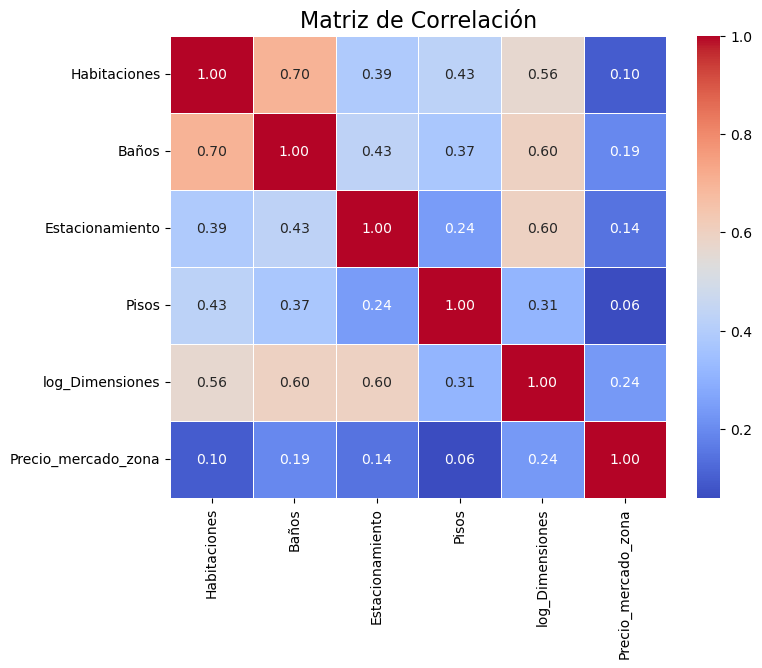

In [6]:
### ---- MATRIZ DE CORRELACIÓN
matriz_corr = df[["Habitaciones","Baños","Estacionamiento","Pisos","log_Dimensiones","Precio_mercado_zona"]].corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación', fontsize=16)
plt.show()

La matriz final muestra que las variables estan relacionadas moderadamente y que ninguna de las variables muestra colinealidad entre entre sí, por lo que no será necesario eliminar más.

## Preprocesamiento

Las variables fueron divididas en tres grupos:
- Variables físicas.
- Variables de mercado.
- Variables categóricas.

Las variables numéricas fueron estandarizadas mientras que las categóricas se transformaron mediante One-Hot Encoding.

In [7]:
### ---- SELECCIÓN DE VARIABLES 

# Variables físicas
features_fisicas = ['log_Dimensiones', 'Habitaciones', 'Baños', 'Estacionamiento', 'Pisos']
# Variables de mercado
features_mercado = ['Precio_mercado_zona']
# Variables categóricas
cat_features = ['Tipo']
cluster_feature = ['Cluster']

print("Distribución de Cluster:")
print(df['Cluster'].value_counts().sort_index())

Distribución de Cluster:
Cluster
C1     377
C2    1749
C3     148
C4    1222
C5     457
C6     264
D1     479
D2     579
D3     598
D4    1203
Name: count, dtype: int64


División del dataset en train y test en relación al cluster.

In [8]:
### ---- SPLIT TRAIN / TEST
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Cluster'])

train = train.reset_index(drop=True)
test  = test.reset_index(drop=True)

# Clasificador y predictor de precio

## Clasificador de Cluster

In [9]:
### ---- CLASIFICADOR DE CLUSTER
features_cluster = features_mercado + features_fisicas + cat_features

X_cls = train[features_cluster]
y_cls = train['Cluster']

X_cls_test = test[features_cluster]
y_cls_test = test['Cluster']

preprocessor_cls = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_mercado + features_fisicas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)])


In [10]:
### ---- RANDOM FOREST CLASSIFIER
clf_rf = Pipeline(steps=[
    ('prep', preprocessor_cls),
    ('model', RandomForestClassifier(random_state=42))])

### ---- BÚSQUEDA DE HIPERPARÁMETROS
param_rf = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__max_depth': [5, 10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']}

### ---- RANDOMIZED SEARCH CV
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    estimator=clf_rf,
    param_distributions=param_rf,
    n_iter=30,
    cv=cv_clf,
    # scoring='accuracy',
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)


### ---- MEJOR MODELO
rf_search.fit(X_cls, y_cls)
best_rf_cluster = rf_search.best_estimator_

print("=== Mejores Parámetros ===")
print(rf_search.best_params_)

# print("\n=== Accuracy Promedio CV ===")
print("\n=== F1-weighted Promedio CV ===")
print(f"{rf_search.best_score_:.4f}")



### ---- PREDICCIÓN
y_pred_cls_rf = best_rf_cluster.predict(X_cls_test)

print("\n=== Random Forest Classifier Optimizado ===")
print(f"Accuracy Test: {accuracy_score(y_cls_test, y_pred_cls_rf):.4f}")
print(classification_report(y_cls_test, y_pred_cls_rf))

=== Mejores Parámetros ===
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 15}

=== F1-weighted Promedio CV ===
0.9666

=== Random Forest Classifier Optimizado ===
Accuracy Test: 0.9682
              precision    recall  f1-score   support

          C1       0.99      1.00      0.99        75
          C2       0.99      0.97      0.98       350
          C3       0.96      0.83      0.89        30
          C4       0.93      0.97      0.95       244
          C5       0.92      1.00      0.96        91
          C6       0.98      0.83      0.90        53
          D1       1.00      0.99      0.99        96
          D2       0.96      0.95      0.96       116
          D3       0.99      0.95      0.97       120
          D4       0.96      1.00      0.98       241

    accuracy                           0.97      1416
   macro avg       0.97      0.95      0.96      1416
weighted avg     

El modelo Random Forest indica una buena capacidad para identificar el segmento de mercado de un inmueble nuevo.

Los errores de clasificación se concentran principalmente en clusters con menor representación, mientras que los segmentos con mayor número de observaciones presentan métricas de precisión y recall superiores.

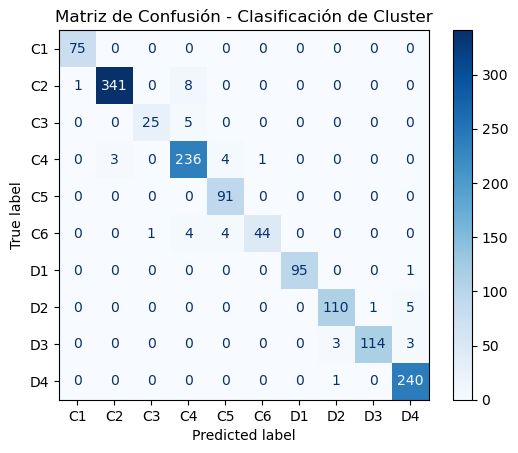

In [11]:
### ---- MATRIZ DE CONFUSIÓN
ConfusionMatrixDisplay.from_estimator(
    best_rf_cluster,
    X_cls_test,
    y_cls_test,
    cmap='Blues')

plt.title('Matriz de Confusión - Clasificación de Cluster')
plt.show()

## Pred Precio

In [12]:
### ---- REGRESOR DE PRECIO
features_precio_num = features_fisicas + features_mercado  
features_precio_cat = cat_features + cluster_feature

X_train = train[features_precio_num + features_precio_cat]
y_train = train['log_Precio']

X_test = test[features_precio_num + features_precio_cat]
y_test = test['log_Precio']

preprocessor_precio = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_precio_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_precio_cat)
    ])

X_train_processed = preprocessor_precio.fit_transform(X_train)
X_test_processed  = preprocessor_precio.transform(X_test)

ohe_cols = preprocessor_precio.named_transformers_['cat'].get_feature_names_out(features_precio_cat).tolist()
feature_names = features_precio_num + ohe_cols


In [13]:
### ---- FUNCIÓN DE MÉTRICAS
def evaluar_modelo(nombre, y_true_log, y_pred_log):
    r2   = r2_score(y_true_log, y_pred_log)
    mae  = mean_absolute_error(y_true_log, y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))

    # Revertimos el log para métricas en MXN
    y_true_mxn = np.exp(y_true_log)
    y_pred_mxn = np.exp(y_pred_log)
    mae_mxn  = mean_absolute_error(y_true_mxn, y_pred_mxn)
    rmse_mxn = np.sqrt(mean_squared_error(y_true_mxn, y_pred_mxn))
    mape_mxn = np.mean(np.abs((y_true_mxn - y_pred_mxn) / y_true_mxn)) * 100
    rmse_relativo = rmse_mxn / y_true_mxn.mean() * 100

    print(f"\n=== {nombre} ===")
    print(f"R²:         {r2:.4f}")
    print(f"MAE (log):  {mae:.4f}")
    print(f"RMSE (log): {rmse:.4f}")
    print(f"MAE (MXN):  ${mae_mxn:,.0f}")
    print(f"RMSE (MXN): ${rmse_mxn:,.0f}")
    print(f"MAPE (MXN): {mape_mxn:.1f}%")
    print(f"RMSE relativo: {rmse_relativo:.1f}%")

    return {'nombre': nombre, 'r2': r2, 'mae_log': mae, 'rmse_log': rmse,
            'mae_mxn': mae_mxn, 'rmse_mxn': rmse_mxn, 'mape_mxn': mape_mxn, 'rmse_rel': rmse_relativo}


#### Regresión Lineal

In [14]:
### ---- ENTRENAMIENTO Y EVALUACIÓN DE REGRESIÓN LINEAL
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
y_pred_lr = lr.predict(X_test_processed)

eval_lr = evaluar_modelo("Regresión Lineal", y_test, y_pred_lr)


=== Regresión Lineal ===
R²:         0.6532
MAE (log):  0.4016
RMSE (log): 0.5780
MAE (MXN):  $15,033,117
RMSE (MXN): $425,080,682
MAPE (MXN): 126.7%
RMSE relativo: 5039.4%


#### Random Forest

In [15]:
### ---- ENTRENAMIENTO Y EVALUACIÓN CON RANDOM FOREST
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
rf.fit(X_train_processed, y_train)
y_pred_rf = rf.predict(X_test_processed)

eval_rf = evaluar_modelo("Random Forest", y_test, y_pred_rf)


=== Random Forest ===
R²:         0.7711
MAE (log):  0.3228
RMSE (log): 0.4696
MAE (MXN):  $3,094,966
RMSE (MXN): $10,920,538
MAPE (MXN): 38.6%
RMSE relativo: 129.5%


In [16]:
### ---- OPTIMIZACIÓN DE HIPERPARÁMETROS — RANDOM FOREST REGRESSOR
pipe_rf_reg = Pipeline([
    ('prep', preprocessor_precio),
    ('model', RandomForestRegressor(random_state=42)) ])

param_rf_reg = {
    'model__n_estimators': [200, 300, 400, 500, 600],
    'model__max_depth': [10, 15, 20, 25, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']}

cv_rf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

rf_reg_search = RandomizedSearchCV(
    estimator=pipe_rf_reg,
    param_distributions=param_rf_reg,
    n_iter=50,
    scoring='r2',
    cv=cv_rf,
    n_jobs=-1,
    random_state=42,
    verbose=1)

rf_reg_search.fit(X_train, y_train)

print("=== Mejores parámetros RF ===")
print(rf_reg_search.best_params_)

print(f"\n=== Mejor R² CV RF ===")
print(f"{rf_reg_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
=== Mejores parámetros RF ===
{'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}

=== Mejor R² CV RF ===
0.7659


In [17]:
### ---- EVALUACIÓN DEL MODELO CON HIPERPARÁMETRO
y_pred_rf_tuned = rf_reg_search.best_estimator_.predict(X_test)

eval_rf_tuned = evaluar_modelo(
    "Random Forest Tuned",
    y_test,
    y_pred_rf_tuned
)


=== Random Forest Tuned ===
R²:         0.7837
MAE (log):  0.2939
RMSE (log): 0.4565
MAE (MXN):  $2,878,014
RMSE (MXN): $11,635,337
MAPE (MXN): 35.8%
RMSE relativo: 137.9%


#### XG Boost

In [18]:
### ---- ENTRENAMIENTO Y EVALUACION XGBOOST
xgb_m = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
xgb_m.fit(X_train_processed, y_train)
y_pred_xgb = xgb_m.predict(X_test_processed)
eval_xgb = evaluar_modelo("XGBoost", y_test, y_pred_xgb)


=== XGBoost ===
R²:         0.7824
MAE (log):  0.3225
RMSE (log): 0.4578
MAE (MXN):  $3,041,732
RMSE (MXN): $10,456,893
MAPE (MXN): 37.8%
RMSE relativo: 124.0%


#### Importancia de variables XGBoost

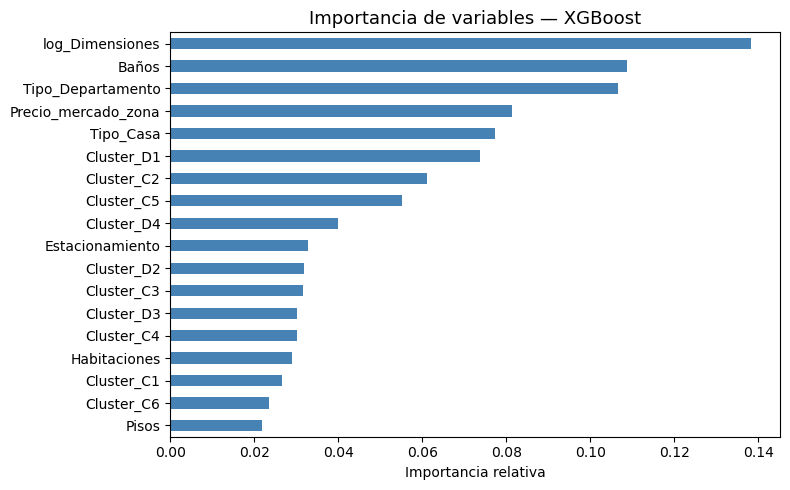

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
importancias = pd.Series(
    xgb_m.feature_importances_,
    index=feature_names          
).sort_values()

importancias.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importancia de variables — XGBoost', fontsize=13)
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()


#### Precio real vs predicho XGBoost


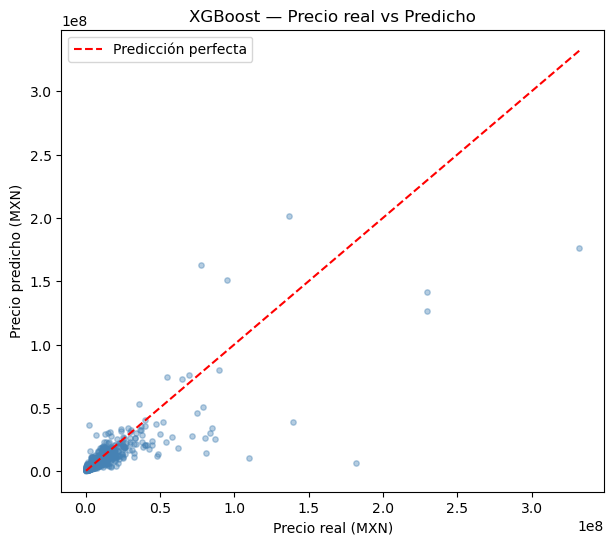

In [20]:
### ---- PRECIO REAL VS PREDICHO
y_real_mxn = np.exp(y_test)
y_pred_mxn = np.exp(y_pred_xgb)

plt.figure(figsize=(7, 6))
plt.scatter(y_real_mxn, y_pred_mxn, alpha=0.4, s=15, color='steelblue')
lim = [y_real_mxn.min(), y_real_mxn.max()]
plt.plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Precio real (MXN)')
plt.ylabel('Precio predicho (MXN)')
plt.title('XGBoost — Precio real vs Predicho')
plt.legend()
plt.show()

In [21]:
### ---- OPTIMIZACIÓN DE HIPERPARÁMETROS — XGBoost
pipe_xgb = Pipeline([
    ('prep', preprocessor_precio),
    ('model', xgb.XGBRegressor(random_state=42))])

param_dist = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [4, 5, 6, 7, 8],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'model__subsample': [0.6, 0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'model__min_child_weight': [1, 3, 5],
    'model__gamma': [0, 0.1, 0.2]}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

random_xgb = RandomizedSearchCV(
    estimator=pipe_xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='r2',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1)

random_xgb.fit(X_train, y_train)

print("=== Mejores parámetros ===")
print(random_xgb.best_params_)

print(f"\n=== Mejor R² CV ===")
print(f"{random_xgb.best_score_:.4f}")

y_pred_xgb_tuned = random_xgb.best_estimator_.predict(X_test)

eval_xgb_tuned = evaluar_modelo(
    "XGBoost Tuned",
    y_test,
    y_pred_xgb_tuned)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
=== Mejores parámetros ===
{'model__subsample': 0.8, 'model__n_estimators': 400, 'model__min_child_weight': 1, 'model__max_depth': 6, 'model__learning_rate': 0.08, 'model__gamma': 0, 'model__colsample_bytree': 0.7}

=== Mejor R² CV ===
0.7766

=== XGBoost Tuned ===
R²:         0.7784
MAE (log):  0.3148
RMSE (log): 0.4620
MAE (MXN):  $3,023,245
RMSE (MXN): $10,948,957
MAPE (MXN): 37.4%
RMSE relativo: 129.8%


### Intervalo de Predicción

In [22]:
### ---- REGRESIÓN CUANTÍLICA (INTERVALOS)
# ALPHA_BAJO = 0.05   # percentil 5%
# ALPHA_ALTO = 0.95   # percentil 95%

# gbr_low = GradientBoostingRegressor(
#     loss='quantile', alpha=ALPHA_BAJO,
#     n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42
# )
# gbr_high = GradientBoostingRegressor(
#     loss='quantile', alpha=ALPHA_ALTO,
#     n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42
# )

# gbr_low.fit(X_train_processed, y_train)
# gbr_high.fit(X_train_processed, y_train)

# y_pred_low_log  = gbr_low.predict(X_test_processed)
# y_pred_high_log = gbr_high.predict(X_test_processed)

# # Revertir a MXN
# y_pred_low_mxn  = np.exp(y_pred_low_log)
# y_pred_high_mxn = np.exp(y_pred_high_log)
# y_real_mxn_int  = np.exp(y_test)

# # Cobertura empírica: % de veces que el precio real cae dentro del intervalo
# cobertura = np.mean((y_real_mxn_int >= y_pred_low_mxn) & (y_real_mxn_int <= y_pred_high_mxn)) * 100
# print(f"Intervalo de predicción al {round((ALPHA_ALTO - ALPHA_BAJO) * 100)}%")
# print(f"Cobertura empírica en test: {cobertura:.1f}%")
# print(f"Amplitud promedio del intervalo: ${np.mean(y_pred_high_mxn - y_pred_low_mxn):,.0f} MXN")


### ---- REGRESIÓN CUANTÍLICA (INTERVALOS)
ALPHA_BAJO = 0.05   # percentil 5%
ALPHA_ALTO = 0.95   # percentil 95%

pipe_gbr_low = Pipeline([
    ('prep', preprocessor_precio),
    ('model', GradientBoostingRegressor(
        loss='quantile', alpha=ALPHA_BAJO,
        n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42
    ))
])

pipe_gbr_high = Pipeline([
    ('prep', preprocessor_precio),
    ('model', GradientBoostingRegressor(
        loss='quantile', alpha=ALPHA_ALTO,
        n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42
    ))
])

pipe_gbr_low.fit(X_train, y_train)
pipe_gbr_high.fit(X_train, y_train)

y_pred_low_log  = pipe_gbr_low.predict(X_test)
y_pred_high_log = pipe_gbr_high.predict(X_test)

# Revertir a MXN
y_pred_low_mxn  = np.exp(y_pred_low_log)
y_pred_high_mxn = np.exp(y_pred_high_log)
y_real_mxn_int  = np.exp(y_test)

# Cobertura empírica
cobertura = np.mean((y_real_mxn_int >= y_pred_low_mxn) & (y_real_mxn_int <= y_pred_high_mxn)) * 100
print(f"Intervalo de predicción al {round((ALPHA_ALTO - ALPHA_BAJO) * 100)}%")
print(f"Cobertura empírica en test: {cobertura:.1f}%")
print(f"Amplitud promedio del intervalo: ${np.mean(y_pred_high_mxn - y_pred_low_mxn):,.0f} MXN")

Intervalo de predicción al 90%
Cobertura empírica en test: 89.0%
Amplitud promedio del intervalo: $12,324,065 MXN


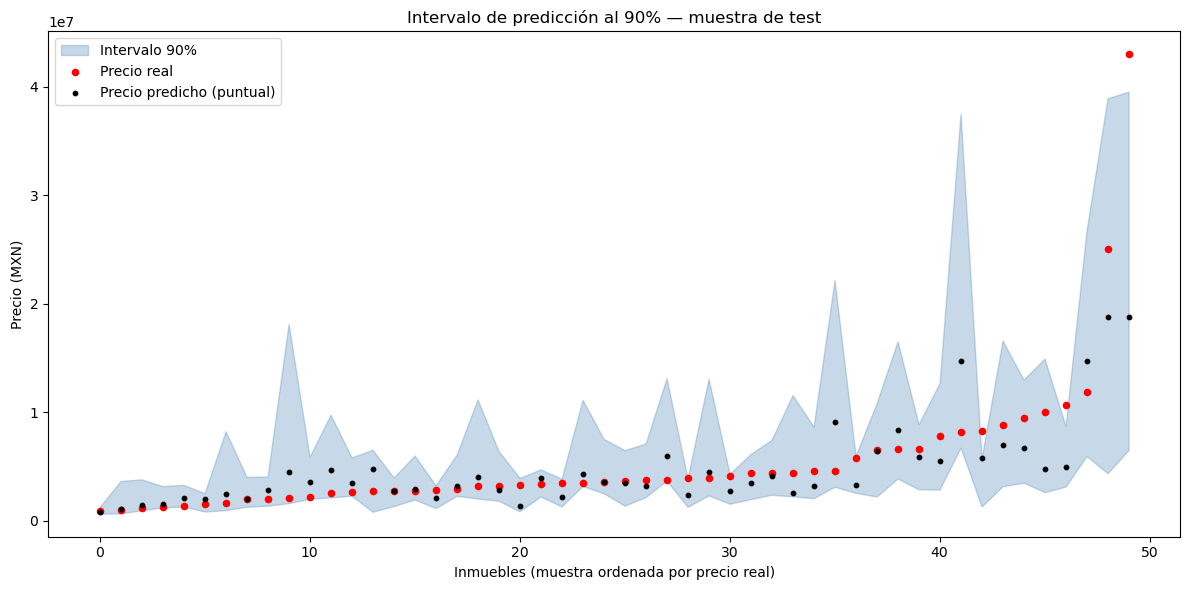

In [23]:
### ---- VISUALIZACIÓN DE INTERVALOS (muestra de 50 inmuebles)
np.random.seed(42)
idx_muestra = np.random.choice(len(y_test), size=min(50, len(y_test)), replace=False)
idx_muestra = np.sort(idx_muestra)

orden = np.argsort(y_real_mxn_int.values[idx_muestra])
idx_ordenado = idx_muestra[orden]

plt.figure(figsize=(12, 6))
x_axis = np.arange(len(idx_ordenado))

plt.fill_between(x_axis, y_pred_low_mxn[idx_ordenado], y_pred_high_mxn[idx_ordenado],
                 alpha=0.3, color='steelblue', label=f'Intervalo {round((ALPHA_ALTO-ALPHA_BAJO)*100)}%')
plt.scatter(x_axis, y_real_mxn_int.values[idx_ordenado], color='red', s=20, label='Precio real', zorder=3)
plt.scatter(x_axis, np.exp(y_pred_xgb_tuned)[idx_ordenado],
             color='black', s=10, label='Precio predicho (puntual)', zorder=3)

plt.xlabel('Inmuebles (muestra ordenada por precio real)')
plt.ylabel('Precio (MXN)')
plt.title(f'Intervalo de predicción al {round((ALPHA_ALTO-ALPHA_BAJO)*100)}% — muestra de test')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
### ---- TABLA DE RESULTADOS
resultados = pd.DataFrame([
    eval_lr,
    eval_rf, eval_rf_tuned,
    eval_xgb, eval_xgb_tuned
])

resultados = resultados[
    ['nombre',
        'r2',
        'mape_mxn',
        'mae_mxn',
        'rmse_mxn',
        'rmse_rel']]

resultados = resultados.sort_values(by='r2',ascending=False)
resultados

,nombre,r2,mae_mxn,rmse_mxn,mape_mxn,rmse_rel
2,Random Forest Tuned,0.783672,2.878014e+06,1.163534e+07,35.781745,137.938220
3,XGBoost,0.782449,3.041732e+06,1.045689e+07,37.801460,123.967637
4,XGBoost Tuned,0.778396,3.023245e+06,1.094896e+07,37.377421,129.801108
1,Random Forest,0.771102,3.094966e+06,1.092054e+07,38.579247,129.464203
0,Regresión Lineal,0.653207,1.503312e+07,4.250807e+08,126.730989,5039.379083


### Prediccion de inmueble nuevo

Se estableció un mínimo de 10 observaciones para una zona y 15 para un municipio para garantizar que la mediana utilizada como referencia de mercado provenga de una muestra suficientemente representativa.

In [25]:
### ---- TABLAS DE REFERENCIA PARA VARIABLES DE MERCADO
mediana_zona_log      = df.groupby('Zona')['log_Precio'].median()
mediana_municipio_log = df.groupby('Municipio')['log_Precio'].median()
mediana_estado_log    = df.groupby('Estado')['log_Precio'].median()
oferta_zona_ref       = df.groupby('Zona')['log_Precio'].count()
oferta_municipio_ref  = df.groupby('Municipio')['log_Precio'].count()

In [26]:
oferta_zona_ref.describe()

count    368.000000
mean      19.228261
std       37.467327
min        1.000000
25%        1.000000
50%        4.000000
75%       16.000000
max      268.000000
Name: log_Precio, dtype: float64

In [27]:
oferta_municipio_ref.describe()

count    354.000000
mean      19.988701
std       38.236774
min        1.000000
25%        1.000000
50%        4.000000
75%       17.000000
max      268.000000
Name: log_Precio, dtype: float64

Se definió un mínimo de 10 observaciones para el cálculo de la mediana a nivel zona y un mínimo de 15 observaciones a nivel municipio. Cuando una zona no alcanza la cantidad mínima requerida, el sistema utiliza la referencia del municipio correspondiente. Si el municipio tampoco cumple con el umbral establecido, se utiliza la referencia estatal.

In [28]:
UMBRAL_ZONA = 10
UMBRAL_MUNICIPIO = 15

def obtener_precio_mercado_zona(estado, municipio, zona):
    oferta_z = oferta_zona_ref.get(zona, 0)
    oferta_m = oferta_municipio_ref.get(municipio, 0)

    if oferta_z >= UMBRAL_ZONA and zona in mediana_zona_log.index:
        return mediana_zona_log[zona], oferta_z
    if oferta_m >= UMBRAL_MUNICIPIO and municipio in mediana_municipio_log.index:
        return mediana_municipio_log[municipio], oferta_z
    if estado in mediana_estado_log.index:
        return mediana_estado_log[estado], oferta_z
    return np.nan, oferta_z

In [29]:
### ---- FUNCIÓN DE PREDICCIÓN COMPLETA
# def predecir_inmueble(estado, municipio, tipo, dimensiones, habitaciones,
#                        banos, estacionamiento, pisos):

#     # Validaciones
#     if dimensiones <= 0:
#         raise ValueError("Las dimensiones deben ser mayores a cero.")
#     if habitaciones < 0:
#         raise ValueError("Las habitaciones no pueden ser negativas.")
#     if banos < 0:
#         raise ValueError("Los baños no pueden ser negativos.")
#     if estacionamiento < 0:
#         raise ValueError("El estacionamiento no puede ser negativo.")
#     if pisos <= 0:
#         raise ValueError("Los pisos deben ser mayores a cero.")
#     if tipo not in ['Casa', 'Departamento']:
#         raise ValueError("Tipo inválido. Debe ser Casa o Departamento.")


#     zona = f"{estado} - {municipio}"
#     precio_mercado_zona, oferta_zona = obtener_precio_mercado_zona(estado, municipio, zona)

#     if np.isnan(precio_mercado_zona):
#         raise ValueError("No hay referencia de mercado para esa Zona/Municipio/Estado.")

#     # --- Predicción de Cluster
#     fila_cluster = pd.DataFrame([{
#         'Precio_mercado_zona': precio_mercado_zona,
#         'log_Dimensiones':     np.log1p(dimensiones),   # ← corregido: misma escala que el entrenamiento
#         'Habitaciones':        habitaciones,
#         'Baños':               banos,
#         'Estacionamiento':     estacionamiento,
#         'Pisos':               pisos,
#         'Tipo':                tipo
#     }])

#     cluster_pred = best_rf_cluster.predict(fila_cluster[features_cluster])[0]  

#     # --- Predicción de Precio
#     fila_precio = pd.DataFrame([{
#     'log_Dimensiones':    np.log1p(dimensiones),
#     'Habitaciones':       habitaciones,
#     'Baños':              banos,
#     'Estacionamiento':    estacionamiento,
#     'Pisos':              pisos,
#     'Precio_mercado_zona': precio_mercado_zona,   
#     'Tipo':               tipo,
#     'Cluster':            cluster_pred
#     }])

#     X_nuevo = preprocessor_precio.transform(fila_precio[features_precio_num + features_precio_cat])

#     # XGBoost Pipeline
#     precio_log_puntual = random_xgb.best_estimator_.predict(fila_precio[features_precio_num + features_precio_cat])[0]
#     # Modelos cuantílicos
#     precio_log_bajo    = gbr_low.predict(X_nuevo)[0]
#     precio_log_alto    = gbr_high.predict(X_nuevo)[0]

#     precio_puntual = np.exp(precio_log_puntual)
#     precio_bajo    = np.exp(precio_log_bajo)
#     precio_alto    = np.exp(precio_log_alto)

#     return {
#         'Cluster_predicho':               cluster_pred,
#         'Precio_predicho_MXN':            round(precio_puntual, 2),
#         'Intervalo_90%_MXN':              (round(precio_bajo, 2), round(precio_alto, 2)),
#         'Precio_mercado_zona_referencia': round(np.exp(precio_mercado_zona), 2)
#     }



### ---- FUNCIÓN DE PREDICCIÓN COMPLETA
def predecir_inmueble(estado, municipio, tipo, dimensiones, habitaciones,
                       banos, estacionamiento, pisos):

    # Validaciones
    if dimensiones <= 0:
        raise ValueError("Las dimensiones deben ser mayores a cero.")
    if habitaciones < 0:
        raise ValueError("Las habitaciones no pueden ser negativas.")
    if banos < 0:
        raise ValueError("Los baños no pueden ser negativos.")
    if estacionamiento < 0:
        raise ValueError("El estacionamiento no puede ser negativo.")
    if pisos <= 0:
        raise ValueError("Los pisos deben ser mayores a cero.")
    if tipo not in ['Casa', 'Departamento']:
        raise ValueError("Tipo inválido. Debe ser Casa o Departamento.")

    zona = f"{estado} - {municipio}"
    precio_mercado_zona, oferta_zona = obtener_precio_mercado_zona(estado, municipio, zona)

    if np.isnan(precio_mercado_zona):
        raise ValueError("No hay referencia de mercado para esa Zona/Municipio/Estado.")

    # --- Predicción de Cluster
    fila_cluster = pd.DataFrame([{
        'Precio_mercado_zona': precio_mercado_zona,
        'log_Dimensiones':     np.log1p(dimensiones),
        'Habitaciones':        habitaciones,
        'Baños':               banos,
        'Estacionamiento':     estacionamiento,
        'Pisos':               pisos,
        'Tipo':                tipo
    }])

    cluster_pred = best_rf_cluster.predict(fila_cluster[features_cluster])[0]

    # --- Fila para modelos de precio (sin preprocesar — los pipelines lo hacen internamente)
    fila_precio = pd.DataFrame([{
        'log_Dimensiones':     np.log1p(dimensiones),
        'Habitaciones':        habitaciones,
        'Baños':               banos,
        'Estacionamiento':     estacionamiento,
        'Pisos':               pisos,
        'Precio_mercado_zona': precio_mercado_zona,
        'Tipo':                tipo,
        'Cluster':             cluster_pred
    }])

    cols_precio = features_precio_num + features_precio_cat

    # Predicción puntual (XGBoost pipeline)
    precio_log_puntual = random_xgb.best_estimator_.predict(fila_precio[cols_precio])[0]

    # Intervalos cuantílicos (pipelines propios — no necesitan X preprocesado)
    precio_log_bajo = pipe_gbr_low.predict(fila_precio[cols_precio])[0]
    precio_log_alto = pipe_gbr_high.predict(fila_precio[cols_precio])[0]

    precio_puntual = np.exp(precio_log_puntual)
    precio_bajo    = np.exp(precio_log_bajo)
    precio_alto    = np.exp(precio_log_alto)

    return {
        'Cluster_predicho':               cluster_pred,
        'Precio_predicho_MXN':            round(precio_puntual, 2),
        'Intervalo_90%_MXN':              (round(precio_bajo, 2), round(precio_alto, 2)),
        'Precio_mercado_zona_referencia': round(np.exp(precio_mercado_zona), 2)
    }

In [30]:
### ---- EJEMPLO DE USO
ejemplo = predecir_inmueble(
    estado="Jalisco",
    municipio="Guadalajara",
    tipo="Casa",
    dimensiones=180,
    habitaciones=3,
    banos=2,
    estacionamiento=2,
    pisos=2
)

print("Resultado de la predicción:")
print(f"  Cluster predicho:              {ejemplo['Cluster_predicho']}")
print(f"  Precio predicho:               ${ejemplo['Precio_predicho_MXN']:,.2f} MXN")
print(f"  Intervalo 90%:                 ${ejemplo['Intervalo_90%_MXN'][0]:,.2f} — ${ejemplo['Intervalo_90%_MXN'][1]:,.2f} MXN")
print(f"  Precio de mercado zona:        ${ejemplo['Precio_mercado_zona_referencia']:,.2f} MXN")

Resultado de la predicción:
  Cluster predicho:              C2
  Precio predicho:               $5,244,940.50 MXN
  Intervalo 90%:                 $2,949,189.80 — $8,279,269.78 MXN
  Precio de mercado zona:        $5,196,220.00 MXN


# Conclusión